## PROJECT OBJECTIVES 
1. Realise the Top Premium Brokers
2. Realise the VIP Customers
3. Worst Perfoming Brokers by Names

## Project Plan
1. Import Libraries
1. Connect to the Insurace Database
2. Query(Fetch) Data into dataframes
3. Make Visualizations of Perfomance repectively

In [ ]:
#Import Libraries 
import pandas as pd
import pyodbc 
import seaborn as sns 
import matplotlib.pyplot as plt 


## 1. Connect to the Database

In [1]:
#Initialize the connection
database = 'PRACTICE'
server = 'DESKTOP-U507UFU\\MSSQLSERVER01'
#Initialize the Connetion
conn_str =(
    "Driver={SQL Server};"
    f"Server={server};"
    f"Database={database};"
    "Trusted_Connection={yes};"
)
#Establish the Connection

conn = pyodbc.connect(conn_str)

NameError: name 'pyodbc' is not defined

### 2. Query/Fetch data from DB

In [ ]:
query = """
   WITH broker_id_cte AS (
SELECT b.BrokerID, b.BrokerName, p.Premium, b.ReportsTo FROM brokers b
LEFT JOIN policies p
ON b.BrokerID = p.BrokerID
)
SELECT BrokerID, BrokerName, Premium, ReportsTo,
DENSE_RANK()OVER(ORDER BY Premium DESC) AS Ranked_broker
FROM broker_id_cte;
"""
df = pd.read_sql(query,conn)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BrokerID       201 non-null    int64  
 1   BrokerName     201 non-null    object 
 2   Premium        200 non-null    float64
 3   ReportsTo      195 non-null    float64
 4   Ranked_broker  201 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 8.0+ KB


In [11]:
df.head()

,BrokerID,BrokerName,Premium,ReportsTo,Ranked_broker
0,39,Broker_39,1995.0,28.0,1
1,4,Agent X,1990.0,3.0,2
2,28,Broker_28,1984.0,38.0,3
3,8,Broker_8,1975.0,29.0,4
4,13,Broker_13,1952.0,39.0,5


#### Obj1.  Realize top premium brokers

In [ ]:
# By Indivudual Policies

In [12]:
#Step1
#Strip White Spaces From Columns
df.columns = df.columns.str.strip()

In [14]:
#Top 10
Top10 = df.head(10)

Top10.head(11)


,BrokerID,BrokerName,Premium,ReportsTo,Ranked_broker
0,39,Broker_39,1995.0,28.0,1
1,4,Agent X,1990.0,3.0,2
2,28,Broker_28,1984.0,38.0,3
3,8,Broker_8,1975.0,29.0,4
4,13,Broker_13,1952.0,39.0,5
5,22,Broker_22,1948.0,3.0,6
6,14,Broker_14,1943.0,19.0,7
7,11,Broker_11,1941.0,8.0,8
8,1,National,1934.0,NaN,9
9,24,Broker_24,1916.0,2.0,10


In [50]:
Top10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BrokerID       10 non-null     int64  
 1   BrokerName     10 non-null     object 
 2   Premium        10 non-null     int64  
 3   ReportsTo      9 non-null      float64
 4   Ranked_broker  10 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 532.0+ bytes


In [48]:
Top10['Premium'] = Top10['Premium'].astype(int)

#### Visualization

C:\Users\User\AppData\Local\Temp\ipykernel_17496\1288952184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


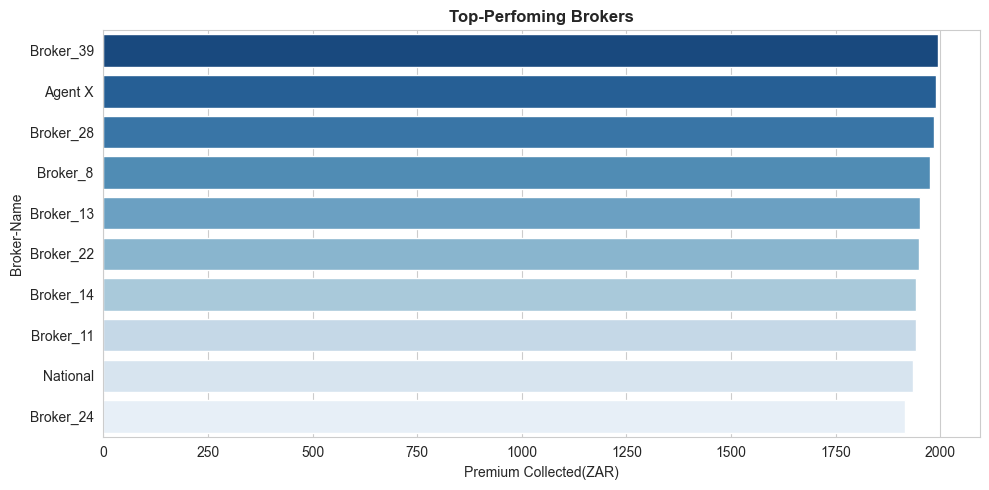

In [53]:
Top10 = Top10.sort_values('Premium', ascending=False) #Descending Order
sns.set_style('whitegrid')
plt.figure(figsize = (10,5))
colors = sns.color_palette("Blues", len(Top10))
sns.barplot(
    data = Top10,
    y = 'BrokerName', 
    x = 'Premium',
    palette = colors[::-1]
)
#Label Axes
plt.title("Top-Perfoming Brokers", fontweight = 'bold')
plt.xlabel("Premium Collected(ZAR)")
plt.ylabel("Broker-Name")
plt.tight_layout()

C:\Users\User\AppData\Local\Temp\ipykernel_17496\3902196784.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


Text(0, 0.5, 'Broker-Name')

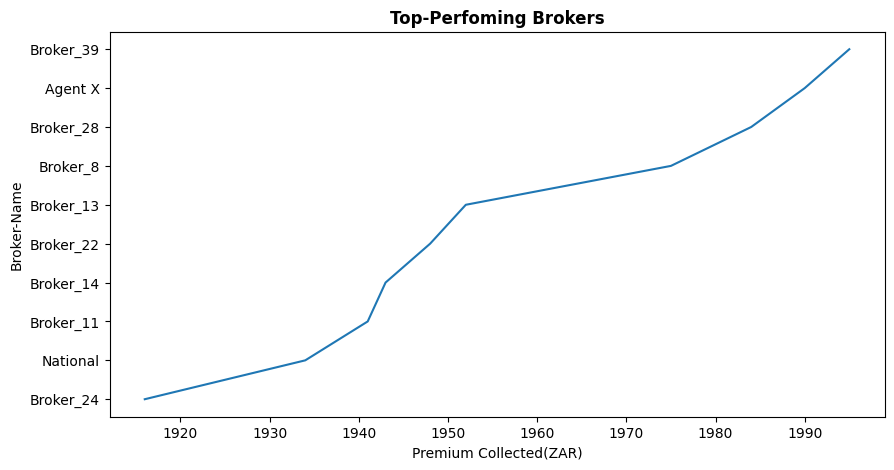

In [37]:
plt.figure(figsize = (10,5))
colors = sns.color_palette("Blues", len(Top10))
sns.lineplot(
    data = Top10,
    y = 'BrokerName', 
    x = 'Premium',
    palette = colors[::-1],
)
#Label Axes
plt.title("Top-Perfoming Brokers", fontweight = 'bold')
plt.xlabel("Premium Collected(ZAR)")
plt.ylabel("Broker-Name")